# Notebook 14 — PCA & Burning Severity Index (BSI)

**Purpose:** Use Principal Component Analysis to derive data-driven feature weights from PC1 loadings, then compute a Burning Severity Index (BSI 0–100). Rainfall is inverted because higher rainfall suppresses burning.

**Input:** `Data/Processed/env_scaled.csv`  
**Output:** `Data/Processed/bsi_scores.csv`

In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt


In [ ]:
# Load scaled data 
X_df      = pd.read_csv('../Data/Processed/env_scaled.csv')
feat_cols = [c for c in X_df.columns if c.endswith('_scaled')]
X         = X_df[feat_cols].values

print(f"Features : {feat_cols}")
print(f"Districts: {len(X_df)}")


Features : ['fire_count_scaled', 'residue_scaled', 'avg_temp_scaled', 'rainfall_scaled']
Districts: 47


In [ ]:
# PCA: fit and inspect variance explained 
pca      = PCA(n_components=len(feat_cols))
pca.fit(X)
variance = pca.explained_variance_ratio_

print("Variance explained per principal component:")
for i, v in enumerate(variance, 1):
    bar = '█' * int(v * 40)
    print(f"  PC{i}: {v:.2%}  {bar}")
print(f"\n  PC1 + PC2 cumulative: {variance[:2].sum():.2%}")



Variance explained per principal component:
  PC1: 53.57%  █████████████████████
  PC2: 33.41%  █████████████
  PC3: 8.83%  ███
  PC4: 4.19%  █

  PC1 + PC2 cumulative: 86.98%


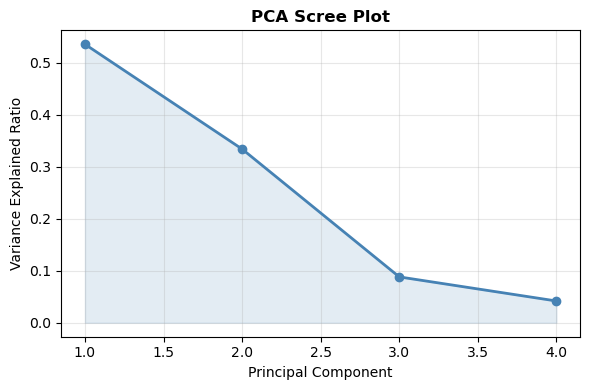

In [5]:
# Scree plot 
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(variance)+1), variance, marker='o', color='steelblue', linewidth=2)
ax.fill_between(range(1, len(variance)+1), variance, alpha=0.15, color='steelblue')
ax.set_title('PCA Scree Plot', fontweight='bold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained Ratio')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../Outputs/Maps/14_pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# PC1 loadings — feature importance for BSI 
loadings = pd.DataFrame({
    'feature' : feat_cols,
    'loading' : pca.components_[0],
}).assign(abs_loading=lambda df: df['loading'].abs())
loadings = loadings.sort_values('abs_loading', ascending=False)

print("PC1 feature loadings (BSI weights will be derived from abs values):")
print(loadings[['feature', 'loading']].to_string(index=False))

PC1 feature loadings (BSI weights will be derived from abs values):
          feature   loading
  rainfall_scaled  0.562751
  avg_temp_scaled -0.537497
fire_count_scaled -0.454377
   residue_scaled -0.433532


In [7]:
# Compute BSI using PC1-derived weights 
# Weight each feature by its absolute PC1 loading (normalised to sum to 1).
weights = np.abs(pca.components_[0])
weights = weights / weights.sum()

print("Derived feature weights:")
for feat, w in zip(feat_cols, weights):
    print(f"  {feat:<25}: {w:.3f}")

# Invert rainfall: higher rainfall → lower fire risk.
# All other features (fire_count, residue, avg_temp) increase with risk.
X_adj = X.copy()
rain_idx = feat_cols.index('rainfall_scaled')
X_adj[:, rain_idx] = -X_adj[:, rain_idx]

raw_score = (X_adj * weights).sum(axis=1)


Derived feature weights:
  fire_count_scaled        : 0.229
  residue_scaled           : 0.218
  avg_temp_scaled          : 0.270
  rainfall_scaled          : 0.283


In [8]:
# Normalise raw score to 0–100 
scaler = MinMaxScaler((0, 100))
bsi    = scaler.fit_transform(raw_score.reshape(-1, 1)).flatten().round(1)

result = pd.DataFrame({'district': X_df['district'], 'BSI': bsi})
result = result.sort_values('BSI', ascending=False).reset_index(drop=True)

print("Top 10 districts by BSI:")
print(result.head(10).to_string(index=False))
print("\nBottom 5 districts by BSI:")
print(result.tail(5).to_string(index=False))


Top 10 districts by BSI:
 district   BSI
  Sangrur 100.0
 Bathinda  95.1
  Muktsar  90.0
  Fazilka  88.5
    Sirsa  84.4
Ferozepur  83.0
Fatehabad  80.8
     Moga  80.6
    Mansa  78.0
    Hisar  77.0

Bottom 5 districts by BSI:
   district  BSI
   Rupnagar 43.7
Yamunanagar 40.8
     Ambala 38.6
  Panchkula 30.8
  Pathankot  0.0


In [9]:
# Save 
result.to_csv('../Data/Processed/bsi_scores.csv', index=False)
print("Saved: Data/Processed/bsi_scores.csv")
print(f"   Rows    : {len(result)}")
print(f"   Columns : {result.columns.tolist()}")


✅ Saved: Data/Processed/bsi_scores.csv
   Rows    : 47
   Columns : ['district', 'BSI']
